# Bid landscape simulation

## Simulate single log-normal market CPM

In [141]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def simulate_market_cpm(
    n=500_000,
    d=6,
    seed=42,

    # Market price (CPM) model: log m_cpm = mu(x) + sigma * eps
    mu0=np.log(1.5),          # baseline median ~ $1.5 CPM when features are ~0
    beta_scale=0.35,          # feature effect on log-CPM
    sigma=0.75,               # lognormal spread

    # Conversion/value model
    base_cvr=2e-4,            # typical display CVR per impression scale (0.0002)
    theta_scale=1.0,          # feature effect on CVR (via sigmoid)
    value_per_conv=50.0,      # $ per conversion (can be arbitrary)
    
    # Bidding rule in CPM dollars
    kappa=0.25,               # scales how aggressively we bid vs value
    bid_cpm_min=0.01,
    bid_cpm_max=20.0,
):
    rng = np.random.default_rng(seed)

    # 1) features
    X = rng.normal(size=(n, d))

    # 2) market price in CPM dollars
    beta = rng.normal(scale=beta_scale, size=d)
    mu = mu0 + X @ beta
    eps = rng.normal(size=n)
    log_m_cpm = mu + sigma * eps
    m_cpm = np.exp(log_m_cpm)  # market clearing price in CPM dollars

    # 3) conversion probability per impression (keep it small!)
    theta = rng.normal(scale=theta_scale, size=d)
    p = sigmoid(X @ theta)                 # in (0,1)
    p_conv = base_cvr * p                  # in (0, base_cvr)

    # 4) value per impression in dollars, then convert to CPM dollars
    value_per_imp_dollars = value_per_conv * p_conv
    value_cpm = 1000.0 * value_per_imp_dollars

    # 5) bid policy (CPM)
    bid_cpm = kappa * value_cpm
    bid_cpm = np.clip(bid_cpm, bid_cpm_min, bid_cpm_max)

    # 6) win + pay (pay = market price if win; 0 otherwise)
    win = (bid_cpm >= m_cpm).astype(np.int8)
    pay_cpm = m_cpm * win
    pay_dollars = pay_cpm / 1000.0

    return {
        "X": X,
        "market_price_cpm": m_cpm,
        "bid_cpm": bid_cpm,
        "win": win,
        "pay_cpm": pay_cpm,
        "pay_dollars": pay_dollars,
        "p_conv": p_conv,
        "value_cpm": value_cpm,
        "params": {"mu0": mu0, "beta": beta, "sigma": sigma}
    }

## Simulate mixture log-normal market model

In [142]:
def simulate_market_cpm_mixture(
    n=300_000,
    d=6,
    seed=42,

    # Two lognormal components in log-CPM space:
    # log M_k = mu_k(x) + sigma_k * eps
    mu0_1=np.log(1.0),         # component 1 baseline median ~$1.0
    mu0_2=np.log(3.0),         # component 2 baseline median ~$3.0
    beta_scale_1=0.25,
    beta_scale_2=0.25,
    sigma1=0.65,
    sigma2=0.85,

    # Mixing weight: pi(x)=P(component=2 | x)
    # If pi_feat_scale=0 => constant mixing prob pi0
    pi0=0.25,                  # unconditional weight on expensive regime
    pi_feat_scale=1.0,         # set 0.0 for constant mixing

    # Optional: keep same value/bid pipeline as before
    base_cvr=2e-4,
    theta_scale=1.0,
    value_per_conv=50.0,
    kappa=0.25,
    bid_cpm_min=0.05,
    bid_cpm_max=10.0,
):
    rng = np.random.default_rng(seed)

    # 1) features
    X = rng.normal(size=(n, d))

    # 2) mixture weight pi(x)
    if pi_feat_scale == 0.0:
        pi = np.full(n, pi0)
        pi_params = {"pi0": pi0, "pi_feat_scale": 0.0, "a": None}
    else:
        a = rng.normal(scale=pi_feat_scale, size=d)
        # shift so average ~ pi0
        logits = X @ a + np.log(pi0 / (1 - pi0))
        pi = sigmoid(logits)
        pi_params = {"pi0": pi0, "pi_feat_scale": pi_feat_scale, "a": a}

    # sample component: c=1 is expensive regime (component 2), c=0 is cheap regime (component 1)
    c = (rng.random(n) < pi).astype(np.int8)

    # 3) component-specific mu(x)
    beta1 = rng.normal(scale=beta_scale_1, size=d)
    beta2 = rng.normal(scale=beta_scale_2, size=d)
    mu1 = mu0_1 + X @ beta1
    mu2 = mu0_2 + X @ beta2

    # 4) sample log-CPM from selected component
    eps = rng.normal(size=n)
    log_m = np.where(c == 0, mu1 + sigma1 * eps, mu2 + sigma2 * eps)
    m_cpm = np.exp(log_m)

    # 5) value model -> bid (same as before)
    theta = rng.normal(scale=theta_scale, size=d)
    p = sigmoid(X @ theta)
    p_conv = base_cvr * p

    value_per_imp_dollars = value_per_conv * p_conv
    value_cpm = 1000.0 * value_per_imp_dollars

    bid_cpm = np.clip(kappa * value_cpm, bid_cpm_min, bid_cpm_max)

    # 6) win + pay (synthetic: pay=market price if win)
    win = (bid_cpm >= m_cpm).astype(np.int8)
    pay_cpm = m_cpm * win
    pay_dollars = pay_cpm / 1000.0

    return {
        "X": X,
        "market_price_cpm": m_cpm,
        "component": c,  # 0=cheap, 1=expensive
        "pi": pi,        # mixing prob for expensive component
        "bid_cpm": bid_cpm,
        "win": win,
        "pay_cpm": pay_cpm,
        "pay_dollars": pay_dollars,
        "p_conv": p_conv,
        "value_cpm": value_cpm,
        "params": {
            "mu0_1": mu0_1, "mu0_2": mu0_2,
            "beta1": beta1, "beta2": beta2,
            "sigma1": sigma1, "sigma2": sigma2,
            **pi_params
        }
    }

In [143]:
def bid_landscape_curves(market_price_cpm, bid_grid_cpm):
    """
    Returns:
      win_rate[b] = P(win | bid=b)
      e_cpm[b]    = E[pay_cpm per impression | bid=b]
    """
    m = market_price_cpm[:, None]     # (n,1)
    B = bid_grid_cpm[None, :]         # (1,K)
    win = (B >= m)                    # (n,K)
    win_rate = win.mean(axis=0)       # (K, )
    e_pay_cpm = (m * win).mean(axis=0)  # expected paid CPM per impression# (K, )
    return win_rate, e_pay_cpm

## Plot bid landscape curves

(80,)
(80,)


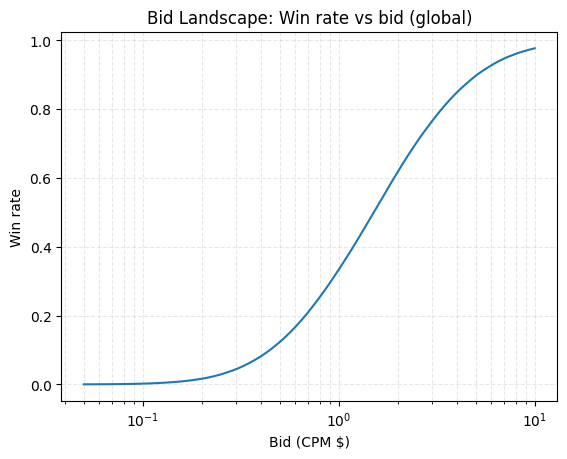

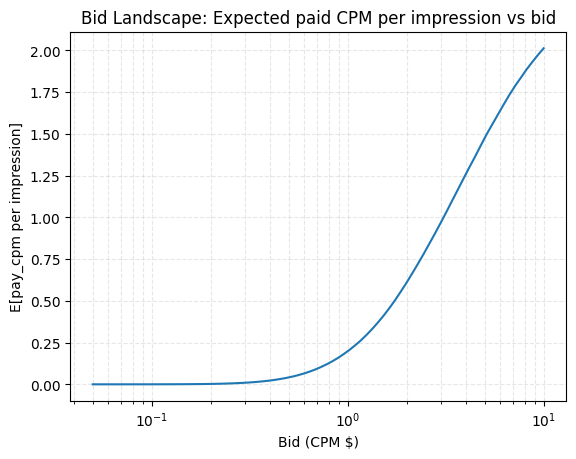

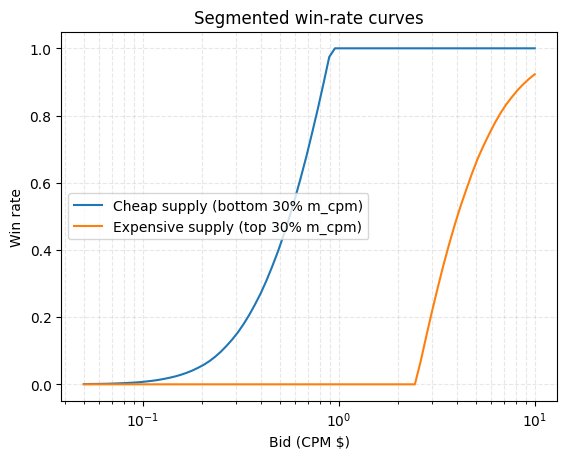

In [144]:
import matplotlib.pyplot as plt

sim = simulate_market_cpm(
    n=300_000, d=6, seed=7,
    mu0=np.log(1.5), beta_scale=0.35, sigma=0.75,
    base_cvr=2e-4, value_per_conv=50.0,
    kappa=0.25,
    bid_cpm_min=0.05, bid_cpm_max=10.0,   # force bids into your target range
)

m = sim["market_price_cpm"]
bids = np.geomspace(0.05, 10.0, 80)

win_rate, e_pay_cpm = bid_landscape_curves(m, bids)

print(win_rate.shape)
print(e_pay_cpm.shape)

# 1) Global win-rate curve
plt.figure()
plt.semilogx(bids, win_rate)
plt.xlabel("Bid (CPM $)")
plt.ylabel("Win rate")
plt.title("Bid Landscape: Win rate vs bid (global)")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

# 2) Global expected spend (CPM) per impression
plt.figure()
plt.semilogx(bids, e_pay_cpm)
plt.xlabel("Bid (CPM $)")
plt.ylabel("E[pay_cpm per impression]")
plt.title("Bid Landscape: Expected paid CPM per impression vs bid")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

# 3) Segment the landscape by "supply expensiveness" (top/bottom 30% by market price)
q_lo, q_hi = np.quantile(m, [0.3, 0.7])
seg_lo = m <= q_lo
seg_hi = m >= q_hi

wr_lo, e_lo = bid_landscape_curves(m[seg_lo], bids)
wr_hi, e_hi = bid_landscape_curves(m[seg_hi], bids)

plt.figure()
plt.semilogx(bids, wr_lo, label="Cheap supply (bottom 30% m_cpm)")
plt.semilogx(bids, wr_hi, label="Expensive supply (top 30% m_cpm)")
plt.xlabel("Bid (CPM $)")
plt.ylabel("Win rate")
plt.title("Segmented win-rate curves")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

## Simple feature dependent MLE(Maximum Log-likelihood Estimation) fit
Market CPM multi-variant-log-normal model with parameters M ~ (w, b and $\sigma$)
- $
Y = \log M, \qquad 
Y \mid x \sim \mathcal{N}(\mu(x), \sigma^2), \qquad 
\mu(x) = w^\top x + b
$  

We fit w, b and $\sigma$ based on  
- All impressions contribute win/loss likelihood (Cases A/B)
- Wins with prices additionally contribute density likelihood 

In [145]:
import numpy as np
from math import sqrt, pi

# Stable normal CDF/PDF approximations (good enough for training)
def normal_pdf(z):
    return np.exp(-0.5 * z**2) / sqrt(2*pi)

def normal_cdf(z):
    # Abramowitz-Stegun approximation for erf-based CDF
    # Phi(z)=0.5*(1+erf(z/sqrt(2)))
    # We'll use a fast approximation to erf for numpy arrays.
    # erf(x) approx: sign(x)*sqrt(1-exp(-x^2*(4/pi + a*x^2)/(1+a*x^2)))
    a = 0.147
    x = z / sqrt(2)
    sign = np.sign(x)
    xx = x*x
    erf = sign * np.sqrt(1 - np.exp(-xx*(4/pi + a*xx)/(1 + a*xx)))
    return 0.5 * (1 + erf)

def fit_lognormal_censored(
    X, bid_cpm, win,
    win_price_cpm=None,      # array same length as X, NaN where missing
    lr=0.05,
    steps=2000,
    l2=1e-4,
    seed=0
):
    """
    clamp + sigma prior (shrinkage) arguments
    """
    sigma_min=0.3
    sigma_max=1.5
    sigma0=0.8
    lambda_sigma=1.0   # try 0.2 ~ 5.0
    """
    Model: log M ~ N(mu(x), sigma^2), mu(x)=b + w^T x
    Observations:
      - loss: M > bid => log-survival
      - win no price: M <= bid => log-CDF
      - win with price: log-density at observed log(price)
    """
    rng = np.random.default_rng(seed)
    n, d = X.shape

    # Add intercept column
    X1 = np.concatenate([np.ones((n,1)), X], axis=1)  # (n, d+1)
    D = d + 1

    # params
    theta = rng.normal(scale=0.01, size=D)  # intercept + weights
    log_sigma = np.log(0.8)                 # reasonable init

    eps = 1e-12

    # prepare logs
    t = np.log(np.clip(bid_cpm, 1e-6, None))

    has_price = None
    y = None
    if win_price_cpm is not None:
        has_price = np.isfinite(win_price_cpm) & (win == 1)
        y = np.log(np.clip(win_price_cpm, 1e-6, None))
    else:
        has_price = np.zeros(n, dtype=bool)

    win = win.astype(np.int8)

    for s in range(steps):
        sigma = np.exp(log_sigma)
        mu = X1 @ theta                    # (n,)
        zt = (t - mu) / sigma              # (n,)
        Phi = np.clip(normal_cdf(zt), eps, 1 - eps)
        phi = np.clip(normal_pdf(zt), eps, None)

        # ---- Loss / Win(no price) terms ----
        # logL = win_no_price * log Phi + loss * log(1-Phi)
        win_no_price = (win == 1) & (~has_price)
        loss = (win == 0)

        # Gradients w.r.t mu and sigma for these terms:
        # For log Phi(zt): d/dmu = -(1/sigma) * (phi/Phi)
        # For log(1-Phi): d/dmu = +(1/sigma) * (phi/(1-Phi))
        ratio_win = phi / Phi
        ratio_loss = phi / (1 - Phi)

        dL_dmu = np.zeros(n)
        dL_dsigma = np.zeros(n)

        # win no price
        dL_dmu[win_no_price] += -(1/sigma) * ratio_win[win_no_price]
        dL_dsigma[win_no_price] += -(zt[win_no_price]/sigma) * ratio_win[win_no_price]

        # loss
        dL_dmu[loss] += +(1/sigma) * ratio_loss[loss]
        dL_dsigma[loss] += +(zt[loss]/sigma) * ratio_loss[loss]

        # ---- Win with observed price density terms ----
        # log f_Y(y) = -log sigma + log phi((y-mu)/sigma)
        # where zy = (y - mu)/sigma
        if has_price.any():
            idx = np.where(has_price)[0]
            zy = (y[idx] - mu[idx]) / sigma
            # d/dmu: +(zy / sigma)
            dL_dmu[idx] += zy / sigma
            # d/dsigma: (-1/sigma) + (zy^2 / sigma)
            dL_dsigma[idx] += (-1/sigma) + (zy**2 / sigma)

        # Convert to gradients for theta and log_sigma
        # mu = X1 theta  => dL/dtheta = X1^T dL/dmu
        grad_theta = X1.T @ dL_dmu / n - l2 * theta
        # sigma = exp(log_sigma): dL/dlog_sigma = dL/dsigma * sigma
        grad_log_sigma = (dL_dsigma.sum() / n) * sigma
        # sigma prior shrinkage
        grad_log_sigma += -2.0 * lambda_sigma * (log_sigma - np.log(sigma0))
        # Ascent on log-likelihood
        theta += lr * grad_theta
        log_sigma += lr * grad_log_sigma
        # hard clamp
        log_sigma = np.clip(log_sigma, np.log(sigma_min), np.log(sigma_max))

        if (s+1) % 200 == 0:
            # compute average log-likelihood (for monitoring)
            sigma = np.exp(log_sigma)
            mu = X1 @ theta
            zt = (t - mu) / sigma
            Phi = np.clip(normal_cdf(zt), eps, 1 - eps)

            ll = 0.0
            ll += np.log(Phi[win_no_price]).sum()
            ll += np.log(1 - Phi[loss]).sum()

            if has_price.any():
                zy = (y[has_price] - mu[has_price]) / sigma
                ll += (-np.log(sigma) - 0.5*zy*zy - 0.5*np.log(2*np.pi)).sum()

            ll /= n
            print(f"step {s+1:4d}  avg_ll={ll:.6f}  sigma={np.exp(log_sigma):.3f}")

    return {
        "theta": theta,          # intercept + weights
        "sigma": np.exp(log_sigma)
    }

## EM mixture model fit

In [146]:
import numpy as np
from math import sqrt, pi as PI

# ---------- Numerics helpers ----------
def logsumexp(a, axis=1):
    m = np.max(a, axis=axis, keepdims=True)
    return (m + np.log(np.sum(np.exp(a - m), axis=axis, keepdims=True))).squeeze(axis)

def logsumexp_2(a0, a1):
    m = np.maximum(a0, a1)
    return m + np.log(np.exp(a0 - m) + np.exp(a1 - m))

# ---------- Mixture fit ----------
def fit_mixture_lognormal_censored_global(
    bid_cpm,
    win,
    win_price_cpm=None,          # NaN where missing
    em_iters=50,
    mstep_gd_steps=30,
    lr=0.06,
    seed=0,
    sigma_min=0.2,
    sigma_max=2.0,
    init_mu=None,
    init_sigma=None,
    init_pi=None,
):
    """
    Fit global 2-component mixture:
        log M ~ pi0 N(mu0, sigma0^2) + pi1 N(mu1, sigma1^2)
    Observations:
      loss: M > bid
      win no price: M <= bid
      win w price: observe price ~= M
    """
    rng = np.random.default_rng(seed)
    eps = 1e-12

    bid_cpm = np.asarray(bid_cpm, dtype=float)
    win = np.asarray(win, dtype=np.int8)
    n = bid_cpm.shape[0]
    t = np.log(np.clip(bid_cpm, 1e-6, None))

    if win_price_cpm is None:
        has_price = np.zeros(n, dtype=bool)
        y = np.full(n, np.nan, dtype=float)
    else:
        win_price_cpm = np.asarray(win_price_cpm, dtype=float)
        has_price = np.isfinite(win_price_cpm) & (win == 1)
        y = np.log(np.clip(win_price_cpm, 1e-6, None))

    win_no_price = (win == 1) & (~has_price)
    loss = (win == 0)

    # ---- init ----
    if init_mu is None or init_sigma is None:
        if has_price.any():
            y_obs = y[has_price]
            q1, q2 = np.quantile(y_obs, [0.35, 0.75])
            mu = np.array([q1, q2])
            s0 = np.std(y_obs) + 1e-3
            sigma = np.array([s0, s0])
        else:
            q1, q2 = np.quantile(t, [0.35, 0.75])
            mu = np.array([q1, q2])
            sigma = np.array([0.8, 0.8])
    else:
        mu = np.array(init_mu, dtype=float).copy()
        sigma = np.array(init_sigma, dtype=float).copy()

    sigma = np.clip(sigma, sigma_min, sigma_max)

    if init_pi is None:
        pi_k = np.array([0.6, 0.4], dtype=float)
    else:
        pi_k = np.array(init_pi, dtype=float).copy()
        pi_k = np.clip(pi_k, 1e-6, 1 - 1e-6)
        pi_k /= pi_k.sum()

    def component_term(mu_k, sigma_k):
        zt = (t - mu_k) / sigma_k
        Phi = np.clip(normal_cdf(zt), eps, 1 - eps)
        term = np.zeros(n, dtype=float)

        term[loss] = 1 - Phi[loss]
        term[win_no_price] = Phi[win_no_price]

        if has_price.any():
            idx = np.where(has_price)[0]
            zy = (y[idx] - mu_k) / sigma_k
            fy = np.clip(normal_pdf(zy), eps, None) / sigma_k
            term[idx] = fy

        return np.clip(term, eps, None)

    def mstep_grad(mu_k, log_sigma_k, r_k):
        sigma_k = np.clip(np.exp(log_sigma_k), sigma_min, sigma_max)
        zt = (t - mu_k) / sigma_k
        Phi = np.clip(normal_cdf(zt), eps, 1 - eps)
        phi = np.clip(normal_pdf(zt), eps, None)

        dQ_dmu = 0.0
        dQ_dsigma = 0.0

        if loss.any():
            S = np.clip(1 - Phi[loss], eps, None)
            w = r_k[loss]
            dQ_dmu += np.sum(w * (+(1 / sigma_k) * (phi[loss] / S)))
            dQ_dsigma += np.sum(w * (+(zt[loss] / sigma_k) * (phi[loss] / S)))

        if win_no_price.any():
            F = Phi[win_no_price]
            w = r_k[win_no_price]
            dQ_dmu += np.sum(w * (-(1 / sigma_k) * (phi[win_no_price] / F)))
            dQ_dsigma += np.sum(w * (-(zt[win_no_price] / sigma_k) * (phi[win_no_price] / F)))

        if has_price.any():
            idx = np.where(has_price)[0]
            w = r_k[idx]
            zy = (y[idx] - mu_k) / sigma_k
            dQ_dmu += np.sum(w * (zy / sigma_k))
            dQ_dsigma += np.sum(w * ((-1 / sigma_k) + (zy * zy / sigma_k)))

        dQ_dlog_sigma = dQ_dsigma * sigma_k
        return dQ_dmu, dQ_dlog_sigma

    # ---- EM loop ----
    for it in range(em_iters):
        term0 = component_term(mu[0], sigma[0])
        term1 = component_term(mu[1], sigma[1])

        logp0 = np.log(pi_k[0] + eps) + np.log(term0)
        logp1 = np.log(pi_k[1] + eps) + np.log(term1)

        log_den = logsumexp_2(logp0, logp1)
        r0 = np.exp(logp0 - log_den)
        r1 = 1.0 - r0

        # update weights
        pi_k = np.array([r0.mean(), r1.mean()])
        pi_k = np.clip(pi_k, 1e-6, 1 - 1e-6)
        pi_k /= pi_k.sum()

        # update component params by a few gradient ascent steps
        for k, rk in enumerate([r0, r1]):
            mu_k = mu[k]
            log_sigma_k = np.log(sigma[k])

            for _ in range(mstep_gd_steps):
                g_mu, g_lsig = mstep_grad(mu_k, log_sigma_k, rk)
                mu_k += lr * (g_mu / n)
                log_sigma_k += lr * (g_lsig / n)
                log_sigma_k = np.clip(log_sigma_k, np.log(sigma_min), np.log(sigma_max))

            mu[k] = mu_k
            sigma[k] = np.exp(log_sigma_k)

        # keep ordering stable (so comp0 is cheaper)
        if mu[0] > mu[1]:
            mu = mu[::-1]
            sigma = sigma[::-1]
            pi_k = pi_k[::-1]

    return {"pi": pi_k, "mu": mu, "sigma": sigma}

## Generate synthetic market and bid data, and fit the model.

In [147]:
sim = simulate_market_cpm(n=300_000, d=6, seed=7, bid_cpm_min=0.05, bid_cpm_max=10.0)
X = sim["X"]
bid = sim["bid_cpm"]
win = sim["win"].astype(np.int8)
print(X.shape, bid.shape, win.shape)

# sim = simulate_market_cpm_mixture(
#     n=300_000, d=6, seed=7,
#     mu0_1=np.log(0.8),
#     mu0_2=np.log(4.0),
#     sigma1=0.6,
#     sigma2=0.9,
#     pi0=0.25,
#     pi_feat_scale=1.0,  # set 0.0 to make mixture weight constant
#     bid_cpm_min=0.05, bid_cpm_max=10.0
# )
X = sim["X"]
bid = sim["bid_cpm"]
win = sim["win"].astype(np.int8)

(300000, 6) (300000,) (300000,)


In [148]:
# Observe price only for some wins (e.g., 30% of wins)
rng = np.random.default_rng(0)
price_obs_rate = 1.01
win_price = np.full_like(bid, np.nan, dtype=float)
mask = (win == 1) & (rng.random(len(win)) < price_obs_rate)
win_price[mask] = sim["pay_cpm"][mask]   # equals market_price_cpm in our synthetic world
print(win_price.shape)

(300000,)


In [149]:
# A few sanity checks before fitting the model.
assert len(X) == len(bid) == len(win)
assert X.ndim == 2 and bid.ndim == 1 and win.ndim == 1
assert X.shape[0] == bid.shape[0] == win.shape[0]
assert np.isfinite(bid).all() and (bid > 0).all()
assert set(np.unique(win)).issubset({0, 1})

In [150]:
# Fitting the model using fit_lognormal_censored.
fit = fit_lognormal_censored(X, bid, win, win_price_cpm=win_price, lr=0.08, steps=2000)
print("Fitted model:", fit)
#print("Fitted sigma:", fit["sigma"])

step  200  avg_ll=-0.618804  sigma=0.789
step  400  avg_ll=-0.618806  sigma=0.789
step  600  avg_ll=-0.618806  sigma=0.789
step  800  avg_ll=-0.618806  sigma=0.789
step 1000  avg_ll=-0.618806  sigma=0.789
step 1200  avg_ll=-0.618806  sigma=0.789
step 1400  avg_ll=-0.618806  sigma=0.789
step 1600  avg_ll=-0.618806  sigma=0.789
step 1800  avg_ll=-0.618806  sigma=0.789
step 2000  avg_ll=-0.618806  sigma=0.789
Fitted model: {'theta': array([ 0.44083682, -0.27840369, -0.43454473,  0.07222901, -0.04344868,
        0.20080311, -0.18250956]), 'sigma': 0.788591274306774}


In [151]:
# Fitting the model using fit_mixture_lognormal_censored_global.
fit2 = fit_mixture_lognormal_censored_global(
    bid, win, win_price_cpm=win_price,
    em_iters=60,
    mstep_gd_steps=40,
    lr=0.08,
    sigma_min=0.2, sigma_max=2.0,
    seed=0
)
print("Fitted mixture model:", fit2)

Fitted mixture model: {'pi': array([0.44755408, 0.55244592]), 'mu': array([0.02001683, 1.02029158]), 'sigma': array([0.8595578 , 0.87046147])}


## Global win-rate curve

In [152]:
def predict_winrate(fit, X, bid_grid_cpm):
    n, d = X.shape
    X1 = np.concatenate([np.ones((n,1)), X], axis=1)
    mu = X1 @ fit["theta"]
    sigma = fit["sigma"]
    t = np.log(bid_grid_cpm[None, :])
    z = (t - mu[:, None]) / sigma
    Phi = normal_cdf(z)
    return Phi.mean(axis=0)  # average over X

# ---------- Prediction: win-rate curve ----------
def predict_winrate_mixture_global(fit, bid_grid_cpm):
    eps = 1e-12
    pi_k = fit["pi"]
    mu = fit["mu"]
    sigma = fit["sigma"]

    t = np.log(np.clip(bid_grid_cpm, 1e-6, None))
    z0 = (t - mu[0]) / sigma[0]
    z1 = (t - mu[1]) / sigma[1]
    F0 = np.clip(normal_cdf(z0), eps, 1 - eps)
    F1 = np.clip(normal_cdf(z1), eps, 1 - eps)
    return pi_k[0] * F0 + pi_k[1] * F1


def predict_winrate_mixture_global2(pi_k, mu, sigma, bid_grid_cpm):
    eps = 1e-12
    t = np.log(np.clip(bid_grid_cpm, 1e-6, None))
    z0 = (t - mu[0]) / sigma[0]
    z1 = (t - mu[1]) / sigma[1]
    F0 = np.clip(normal_cdf(z0), eps, 1 - eps)
    F1 = np.clip(normal_cdf(z1), eps, 1 - eps)
    return pi_k[0] * F0 + pi_k[1] * F1

bids = np.geomspace(0.05, 10.0, 80)
wr_hat = predict_winrate(fit, X[:50_000], bids)  # use a sample
wr_hat_mix = predict_winrate_mixture_global(fit2, bids)

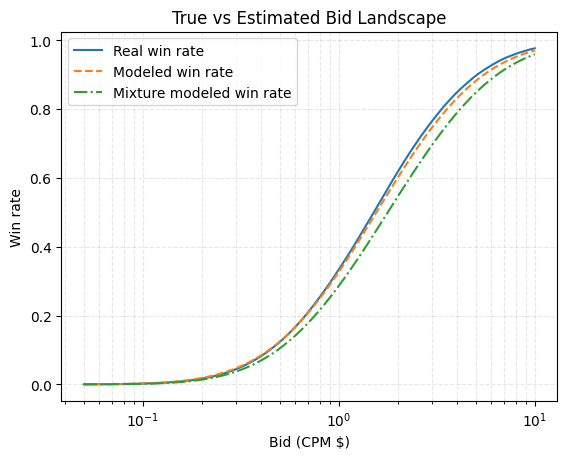

{'theta': array([ 0.44083682, -0.27840369, -0.43454473,  0.07222901, -0.04344868,
        0.20080311, -0.18250956]), 'sigma': 0.788591274306774}
0.0002381976262592482 0.9705737554470368


In [153]:
plt.figure()
plt.semilogx(bids, win_rate, label="Real win rate")
plt.semilogx(bids, wr_hat, label="Modeled win rate", linestyle="--")
plt.semilogx(bids, wr_hat_mix, label="Mixture modeled win rate", linestyle="-.")
plt.xlabel("Bid (CPM $)")
plt.ylabel("Win rate")
plt.title("True vs Estimated Bid Landscape")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend()
plt.show()

print(fit)
print(wr_hat.min(), wr_hat.max())

# print(wr_hat.shape)
# print(win_rate.shape)
# dis = np.linalg.norm(win_rate-wr_hat, ord=2)
# err_percentage = 2*dis/(np.linalg.norm(win_rate) + np.linalg.norm(wr_hat))
# print(dis)
# print(err_percentage)

## Make segment_id from X

In [154]:
def make_seg_id_from_X(X, S=50, seed=0):
    rng = np.random.default_rng(seed)
    n, d = X.shape
    u = rng.normal(size=d)
    u /= (np.linalg.norm(u) + 1e-12)
    score = X @ u
    edges = np.quantile(score, np.linspace(0, 1, S + 1))
    seg_id = np.clip(np.digitize(score, edges[1:-1], right=False), 0, S - 1)
    return seg_id.astype(np.int32)

In [155]:
# seg_id, seg_meta = make_seg_id_from_X(sim["X"], S=50, seed=1, method="projection")

In [156]:
# A few sanity checks to help understanding.

# print(X.shape)
# print(seg_id.shape)
# print(seg_meta)

# i=0
# len_accu = 0
# for s in np.unique(seg_id):
#     idx = np.where(seg_id == s)[0]
#     len_accu += len(idx)
#     print(f"i: {i}, cur: {len(idx)}, accu_len: {len_accu}", idx)
#     i += 1

## Fit per segment mixture model(with shrinkage)

In [157]:
def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def fit_mixture_by_segment_with_shrinkage(
    seg_id,
    bid_cpm,
    win,
    win_price_cpm,
    bids_grid,
    S_min_n=2_000,
    tau=20_000,
    em_iters=40,
    mstep_gd_steps=30,
    lr=0.06,
    seed=0,
    sigma_min=0.2,
    sigma_max=2.0,
):
    seg_id = np.asarray(seg_id).astype(np.int32)
    bid_cpm = np.asarray(bid_cpm, dtype=float)
    win = np.asarray(win, dtype=np.int8)
    win_price_cpm = np.asarray(win_price_cpm, dtype=float)

    # --- global fit used as prior / init ---
    global_fit = fit_mixture_lognormal_censored_global(
        bid_cpm, win, win_price_cpm,
        em_iters=em_iters,
        mstep_gd_steps=mstep_gd_steps,
        lr=lr,
        seed=seed,
        sigma_min=sigma_min,
        sigma_max=sigma_max,
    )

    pi_g, mu_g, sig_g = global_fit["pi"], global_fit["mu"], global_fit["sigma"]
    log_sig_g = np.log(sig_g)
    logit_pi1_g = logit(pi_g[1])

    seg_fit = {}
    seg_fit_shr = {}
    seg_wr = {}
    seg_wr_shr = {}

    uniq = np.unique(seg_id)
    for s in uniq:
        idx = np.where(seg_id == s)[0]
        n_s = len(idx)
        if n_s < S_min_n:
            continue

        # Fit segment mixture, initialized at global (stabilizes a lot)
        f = fit_mixture_lognormal_censored_global(
            bid_cpm[idx], win[idx], win_price_cpm[idx],
            em_iters=em_iters,
            mstep_gd_steps=mstep_gd_steps,
            lr=lr,
            seed=seed + int(s),
            sigma_min=sigma_min,
            sigma_max=sigma_max,
            init_mu=mu_g,
            init_sigma=sig_g,
            init_pi=pi_g,
        )

        seg_fit[int(s)] = {"n": n_s, **f}

        # shrinkage weight
        a = n_s / (n_s + tau)

        # shrink params
        mu_s = f["mu"]
        sig_s = f["sigma"]
        pi_s = f["pi"]

        mu_shr = a * mu_s + (1 - a) * mu_g
        log_sig_shr = a * np.log(sig_s) + (1 - a) * log_sig_g
        sig_shr = np.exp(log_sig_shr)

        logit_pi1_s = logit(pi_s[1])
        logit_pi1_shr = a * logit_pi1_s + (1 - a) * logit_pi1_g
        pi1_shr = sigmoid(logit_pi1_shr)
        pi_shr = np.array([1 - pi1_shr, pi1_shr])

        seg_fit_shr[int(s)] = {"n": n_s, "a": a, "pi": pi_shr, "mu": mu_shr, "sigma": sig_shr}

        # predict curves
        seg_wr[int(s)] = predict_winrate_mixture_global2(pi_s, mu_s, sig_s, bids_grid)
        seg_wr_shr[int(s)] = predict_winrate_mixture_global2(pi_shr, mu_shr, sig_shr, bids_grid)

    return {
        "global_fit": global_fit,
        "seg_fit": seg_fit,
        "seg_fit_shr": seg_fit_shr,
        "seg_wr": seg_wr,
        "seg_wr_shr": seg_wr_shr,
    }

## Compute true win-rate curve per segment (from market prices)

In [158]:
def true_winrate_by_segment(seg_id, market_price_cpm, bids_grid, min_n=2_000):
    seg_id = np.asarray(seg_id)
    m = np.asarray(market_price_cpm)
    out = {}
    for s in np.unique(seg_id):
        idx = np.where(seg_id == s)[0]
        if len(idx) < min_n:
            continue
        # win rate at each bid: mean(1[m <= bid])
        out[int(s)] = (m[idx, None] <= bids_grid[None, :]).mean(axis=0)
    return out

## Get the synthetic data and train the model

In [159]:
bids = np.geomspace(0.05, 10.0, 80)

seg_id = make_seg_id_from_X(sim["X"], S=50, seed=1)

bid = sim["bid_cpm"]
win = sim["win"].astype(np.int8)

# Observe price only for some wins (e.g., 30% of wins)
rng = np.random.default_rng(0)
price_obs_rate = 1.01
win_price = np.full_like(bid, np.nan, dtype=float)
mask = (win == 1) & (rng.random(len(win)) < price_obs_rate)
win_price[mask] = sim["pay_cpm"][mask]   # equals market_price_cpm in our synthetic world

fitS = fit_mixture_by_segment_with_shrinkage(
    seg_id, bid, win, win_price,
    bids_grid=bids,
    S_min_n=2000,
    tau=20000,
    em_iters=40,
    mstep_gd_steps=30,
    lr=0.06
)

wr_true_seg = true_winrate_by_segment(seg_id, sim["market_price_cpm"], bids, min_n=2000)

## Plots a few segments

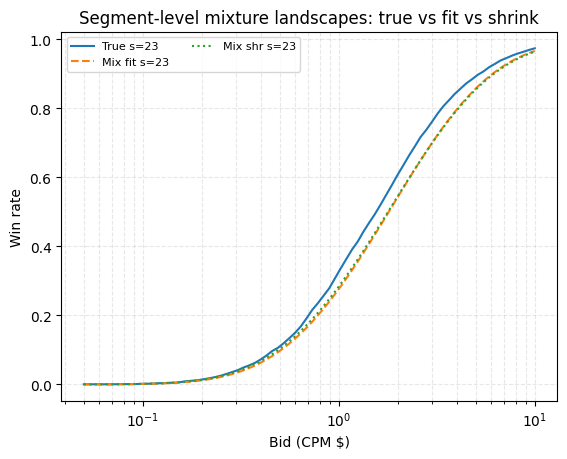

In [160]:
import matplotlib.pyplot as plt

# choose a few biggest segments
sizes = []
for s in fitS["seg_fit"].keys():
    sizes.append((s, fitS["seg_fit"][s]["n"]))
sizes.sort(key=lambda x: -x[1])
to_plot = [s for s,_ in sizes[23:24]]

plt.figure()
for s in to_plot:
    plt.semilogx(bids, wr_true_seg[s], label=f"True s={s}")
    plt.semilogx(bids, fitS["seg_wr"][s], linestyle="--", label=f"Mix fit s={s}")
    plt.semilogx(bids, fitS["seg_wr_shr"][s], linestyle=":", label=f"Mix shr s={s}")

plt.xlabel("Bid (CPM $)")
plt.ylabel("Win rate")
plt.title("Segment-level mixture landscapes: true vs fit vs shrink")
plt.legend(ncol=2, fontsize=8)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

In [161]:
print(sizes)

[(0, 6000), (1, 6000), (2, 6000), (3, 6000), (4, 6000), (5, 6000), (6, 6000), (7, 6000), (8, 6000), (9, 6000), (10, 6000), (11, 6000), (12, 6000), (13, 6000), (14, 6000), (15, 6000), (16, 6000), (17, 6000), (18, 6000), (19, 6000), (20, 6000), (21, 6000), (22, 6000), (23, 6000), (24, 6000), (25, 6000), (26, 6000), (27, 6000), (28, 6000), (29, 6000), (30, 6000), (31, 6000), (32, 6000), (33, 6000), (34, 6000), (35, 6000), (36, 6000), (37, 6000), (38, 6000), (39, 6000), (40, 6000), (41, 6000), (42, 6000), (43, 6000), (44, 6000), (45, 6000), (46, 6000), (47, 6000), (48, 6000), (49, 6000)]


## Heatmap: where the model is biased (segment × bid)

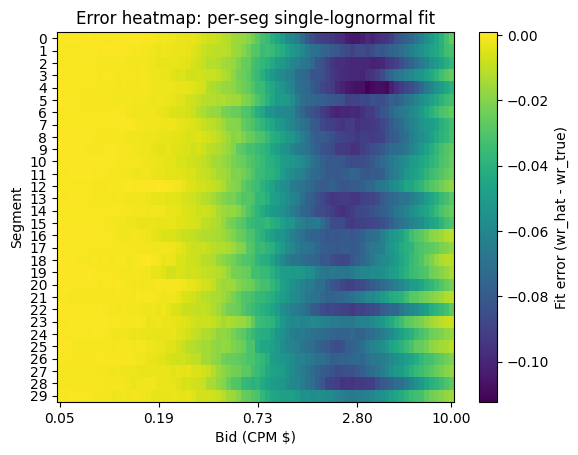

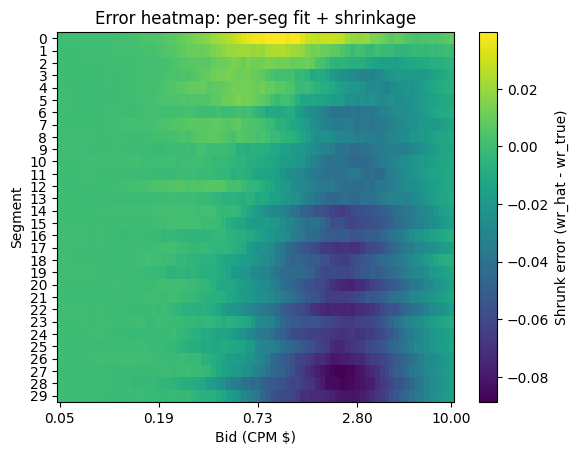

In [162]:
def make_error_heatmap(wr_true_seg, wr_hat_seg, seg_list, bids_grid):
    # returns matrix [num_segs, num_bids]
    E = np.zeros((len(seg_list), len(bids_grid)), dtype=float)
    for i, s in enumerate(seg_list):
        E[i, :] = wr_hat_seg[s] - wr_true_seg[s]
    return E

# choose segments to include in heatmap (top N by size)
N = 30
seg_list = [s for s, _ in sizes[:N]]

E_fit = make_error_heatmap(wr_true_seg, fitS["seg_wr"], seg_list, bids)
E_shr = make_error_heatmap(wr_true_seg, fitS["seg_wr_shr"], seg_list, bids)

plt.figure()
plt.imshow(E_fit, aspect="auto", interpolation="nearest")
plt.colorbar(label="Fit error (wr_hat - wr_true)")
plt.yticks(np.arange(len(seg_list)), [str(s) for s in seg_list])
plt.xticks([0, 20, 40, 60, 79], [f"{bids[i]:.2f}" for i in [0,20,40,60,79]])
plt.xlabel("Bid (CPM $)")
plt.ylabel("Segment")
plt.title("Error heatmap: per-seg single-lognormal fit")
plt.show()

plt.figure()
plt.imshow(E_shr, aspect="auto", interpolation="nearest")
plt.colorbar(label="Shrunk error (wr_hat - wr_true)")
plt.yticks(np.arange(len(seg_list)), [str(s) for s in seg_list])
plt.xticks([0, 20, 40, 60, 79], [f"{bids[i]:.2f}" for i in [0,20,40,60,79]])
plt.xlabel("Bid (CPM $)")
plt.ylabel("Segment")
plt.title("Error heatmap: per-seg fit + shrinkage")
plt.show()

# Complete bidding loop simulator with bid landscape

In [163]:
import numpy as np

# You already have normal_cdf from earlier; re-use it.
# Here is a simple compatible one (fast approximation):
from math import sqrt, pi as PI
def normal_cdf(z):
    a = 0.147
    x = z / sqrt(2)
    sign = np.sign(x)
    xx = x * x
    erf = sign * np.sqrt(1 - np.exp(-xx * (4 / PI + a * xx) / (1 + a * xx)))
    return 0.5 * (1 + erf)

def pwin_lognormal(b_cpm, mu, sigma):
    t = np.log(np.clip(b_cpm, 1e-12, None))
    z = (t - mu) / sigma
    return np.clip(normal_cdf(z), 1e-12, 1 - 1e-12)

def epay_cpm_lognormal(b_cpm, mu, sigma):
    """
    E[pay_cpm per impression] = E[M * 1(M <= b)] for lognormal M.
    Closed form:
      exp(mu + 0.5*sigma^2) * Phi((log b - mu - sigma^2)/sigma)
    """
    t = np.log(np.clip(b_cpm, 1e-12, None))
    z2 = (t - mu - sigma**2) / sigma
    return np.exp(mu + 0.5 * sigma**2) * np.clip(normal_cdf(z2), 1e-12, 1 - 1e-12)

## Discrete conversion delay model

In [188]:
def make_geometric_delay_pmf(D=48, p=0.15):
    """
    Delay PMF over {0..D}, geometric-ish with cutoff at D.
    p: arrival probability per step (larger = faster).
    """
    k = np.arange(D + 1)
    pmf = (1 - p) ** k * p
    pmf[-1] += 1 - pmf.sum()  # shove tail mass into last bucket
    return pmf / pmf.sum()

class DelayBuffer:
    def __init__(self, pmf):
        self.pmf = np.asarray(pmf, dtype=float)
        self.D = len(self.pmf) - 1
        self.buf = np.zeros(self.D + 1, dtype=float)

    def add_new(self, n_new):
        # multinomial split of new conversions into delay buckets
        if n_new <= 0:
            return
        draws = np.random.multinomial(int(n_new), self.pmf)
        self.buf += draws

    def step(self):
        matured = self.buf[0]
        self.buf[:-1] = self.buf[1:]
        self.buf[-1] = 0.0
        return matured

## The complete closed-loop simulator

### Simulate segment mix-shift shock 

In [189]:
def segment_price_stats(seg_id, mkt_price_cpm, S=None):
    seg_id = np.asarray(seg_id).astype(int)
    m = np.asarray(mkt_price_cpm, float)
    if S is None:
        S = seg_id.max() + 1
    med = np.full(S, np.nan)
    cnt = np.zeros(S, dtype=int)
    for s in range(S):
        idx = np.where(seg_id == s)[0]
        cnt[s] = len(idx)
        if cnt[s] > 0:
            med[s] = np.median(m[idx])
    return med, cnt

def build_seg_index(seg_id):
    seg_id = np.asarray(seg_id).astype(int)
    S = seg_id.max() + 1
    seg_to_idx = [None] * S
    for s in range(S):
        seg_to_idx[s] = np.where(seg_id == s)[0]
    return seg_to_idx

def sample_indices_with_seg_weights(rng, seg_to_idx, weights, n_samples):
    """
    weights: length S, sum to 1
    """
    S = len(seg_to_idx)
    segs = rng.choice(S, size=n_samples, p=weights)
    out = np.empty(n_samples, dtype=int)
    for i, s in enumerate(segs):
        pool = seg_to_idx[s]
        out[i] = pool[rng.integers(0, len(pool))]
    return out

### HDMI shadow price solver

In [190]:
import numpy as np

def solve_lambda_for_budget_step(
    V_cpm,             # shape (n_imps,)
    seg_ids,           # shape (n_imps,)
    mu_by_seg, sigma_by_seg,
    budget_step_dollars,
    *,
    bid_cpm_min=0.01,
    bid_cpm_max=50.0,
    lam_lo=1e-6,
    lam_hi=1e6,
    iters=50,
):
    """
    Find lambda so that expected spend (dollars) ~= budget_step_dollars
    using segment-level lognormal landscapes.

    V_cpm must be value per impression in CPM dollars so bid=V/lambda is CPM dollars.
    """
    V_cpm = np.asarray(V_cpm, float)
    seg_ids = np.asarray(seg_ids, int)
    mu_by_seg = np.asarray(mu_by_seg, float)
    sigma_by_seg = np.asarray(sigma_by_seg, float)

    mu = mu_by_seg[seg_ids]
    sig = sigma_by_seg[seg_ids]

    target_total_cpm = 1000.0 * budget_step_dollars  # convert dollars->CPM-sum units

    def total_expected_cpm(lam):
        b = V_cpm / lam
        b = np.clip(b, bid_cpm_min, bid_cpm_max)
        pay_cpm = epay_cpm_lognormal(b, mu, sig)  # vectorized
        return float(pay_cpm.sum())

    # ensure bracket (optional auto-expand)
    lo, hi = lam_lo, lam_hi
    s_lo = total_expected_cpm(lo)
    s_hi = total_expected_cpm(hi)

    # We need s(lo) >= target >= s(hi). If not, expand.
    for _ in range(40):
        if s_lo < target_total_cpm:
            lo /= 10.0
            s_lo = total_expected_cpm(lo)
        elif s_hi > target_total_cpm:
            hi *= 10.0
            s_hi = total_expected_cpm(hi)
        else:
            break

    # binary search on log-scale
    for _ in range(iters):
        mid = np.sqrt(lo * hi)
        s_mid = total_expected_cpm(mid)
        if s_mid > target_total_cpm:
            # spending too high -> increase lambda
            lo = mid
        else:
            hi = mid

    return float(np.sqrt(lo * hi))

### Main run bidding loop

In [232]:
def run_bidding_loop(
    seg_id,
    mkt_price_cpm,
    pconv_true,
    pconv_hat,
    mu_by_seg,
    sigma_by_seg,
    *,
    mu_global=1,
    sigma_global=0,
    # campaign goals
    budget_total_dollars=200.0,
    target_cpa_dollars=50.0,
    value_per_conv_dollars=50.0,   # used only if you prefer value bidding

    # simulation layout
    steps=96,                      # e.g. 96 x 15-min = 1 day
    imps_per_step=50_000,
    seed=0,

    # bidding
    bid_cpm_min=0.01,
    bid_cpm_max=50.0,
    bid_mode="tcpa",               # "tcpa" or "value"
    base_mult=1.0,                 # extra scale knob

    # pacing PID-ish (multiplicative)
    pace_kp=0.25,
    pace_ki=0.02,
    alpha_pace_init=1.0,
    alpha_pace_min=0.05,
    alpha_pace_max=10.0,
    pace_use_expected_spend=False,  # True = HDMI expected spend, False = realized spend
    pace_use_global_exp_s=False,  # True = Global bidlandscape expected spend.

    # tCPA controller (multiplicative)
    cpa_kp=0.20,                   # reacts to log(target/obs)
    alpha_cpa_init=1.0,
    alpha_cpa_min=0.05,
    alpha_cpa_max=10.0,
    cpa_update_every=4,            # update every N steps
    cpa_smooth=0.2,                # EMA on observed CPA

    # shock simulators
    price_shock_step=None,      # e.g., 40
    price_shock_mult=2.0,       # prices multiply by this after shock
    traffic_shock_step=None,    # e.g., 40
    traffic_shock_mult=0.5,     # imps_per_step multiply by this after shock
    mix_shift_step=None,          # e.g. 40
    mix_shift_strength=0.8,       # 0=no change, 1=full shift
    expensive_set=None,           # set of segment ids

    # conversion delay
    delay_pmf=None,
):
    rng = np.random.default_rng(seed)
    n = len(seg_id)
    assert len(mkt_price_cpm) == n
    assert len(pconv_true) == n
    assert len(pconv_hat) == n

    if delay_pmf is None:
        delay_pmf = make_geometric_delay_pmf(D=48, p=0.12)  # ~hours-scale if 15-min steps
    delay = DelayBuffer(delay_pmf)

    # controller state
    alpha_pace = float(alpha_pace_init)
    alpha_cpa = float(alpha_cpa_init)
    pace_int = 0.0
    cpa_ema = None

    # targets per step
    budget_step = budget_total_dollars / steps

    hist = {
        "alpha_pace": [],
        "alpha_cpa": [],
        "lambda": [],
        "spend_real": [],
        "spend_exp": [],
        "spend_global_exp": [],
        "bid_cpm": [],
        "wins": [],
        "convs_new": [],
        "convs_matured": [],
        "cpa_matured": [],
        "pacing_err_log": [],
    }

     # new:
    seg_to_idx = build_seg_index(seg_id)
    S = len(seg_to_idx)
    
    # base weights proportional to segment frequency
    base_w = np.array([len(seg_to_idx[s]) for s in range(S)], dtype=float)
    base_w /= base_w.sum()
    
    # expensive-biased weights
    w_exp = base_w.copy()
    if expensive_set is not None:
        mask = np.zeros(S, dtype=bool)
        mask[list(expensive_set)] = True
        # boost expensive segments by factor k, renormalize
        k = 5.0
        w_exp[mask] *= k
        w_exp /= w_exp.sum()

    # iterate steps
    for t in range(steps):
        # sample a batch of auctions from your dataset (with replacement for simplicity)
        # --- Price shock ---
        actual_imps_per_step = imps_per_step
        if traffic_shock_step is not None and t>=traffic_shock_step:
            actual_imps_per_step = int(imps_per_step*traffic_shock_mult)

        # Uniform sampling across segment
        # idx = rng.integers(0, n, size=actual_imps_per_step)

        # choose weights depending on shock
        w = base_w
        if mix_shift_step is not None and t >= mix_shift_step:
            # convex combination: (1-strength)*base + strength*expensive-biased
            w = (1 - mix_shift_strength) * base_w + mix_shift_strength * w_exp
            w /= w.sum()
        idx = sample_indices_with_seg_weights(rng, seg_to_idx, w, actual_imps_per_step)
        
        s = np.asarray(seg_id)[idx]
        
        m = np.asarray(mkt_price_cpm)[idx]
        # --- Price shock ---
        if price_shock_step is not None and t >= price_shock_step:
            m = m * price_shock_mult    
        
        p_true = np.asarray(pconv_true)[idx]
        p_hat = np.asarray(pconv_hat)[idx]

        mu = np.asarray(mu_by_seg)[s]
        sig = np.asarray(sigma_by_seg)[s]

        # --- base bid ---
        if bid_mode == "tcpa":
            # common tCPA-style: bid ~= 1000 * p(conv) * targetCPA
            base_bid_cpm = 1000.0 * p_hat * target_cpa_dollars * alpha_cpa
        elif bid_mode == "value":
            # value bidding: bid ~= 1000 * p(conv) * value_per_conv
            base_bid_cpm = 1000.0 * p_hat * value_per_conv_dollarsss
        else:
            raise ValueError("bid_mode must be 'tcpa' or 'value'")

        lam = solve_lambda_for_budget_step(
            V_cpm=base_bid_cpm,
            seg_ids=s,
            mu_by_seg=mu_by_seg,
            sigma_by_seg=sigma_by_seg,
            budget_step_dollars=budget_step,
        )

        bid_cpm = np.clip(base_bid_cpm / lam, 0.01, 50.0)
        #bid_cpm = base_mult * alpha_pace * alpha_cpa * base_bid_cpm
        #bid_cpm = np.clip(bid_cpm, bid_cpm_min, bid_cpm_max)

        # --- HDMI predicted spend (expected) ---
        pay_exp_cpm = epay_cpm_lognormal(bid_cpm, mu, sig)
        spend_exp = float(np.sum(pay_exp_cpm) / 1000.0)  # dollars
        pay_global_exp_cpm = epay_cpm_lognormal(bid_cpm, mu_global, sigma_global)
        spend_global_exp = float(np.sum(pay_global_exp_cpm) / 1000.0)  # dollars

        # --- Realized auction (2nd price simplification) ---
        win = (bid_cpm >= m)
        pay_real_cpm = m * win
        spend_real = float(np.sum(pay_real_cpm) / 1000.0)

        # --- Conversions (new + delayed maturity) ---
        # new conversions from won impressions
        convs_new = rng.binomial(n=int(win.sum()), p=float(np.mean(p_true[win])) if win.any() else 0.0)
        delay.add_new(convs_new)
        convs_matured = delay.step()

        # --- Pacing update ---
        spend_for_pacing = spend_exp if pace_use_expected_spend else spend_real
        if pace_use_global_exp_s:
            spend_for_pacing = spend_global_exp
        # log error: positive means under-spending (need to bid up)
        e = np.log((budget_step + 1e-12) / (spend_for_pacing + 1e-12))
        pace_int = 0.98 * pace_int + e  # leaky integrator
        alpha_pace *= np.exp(pace_kp * e + pace_ki * pace_int)
        alpha_pace = float(np.clip(alpha_pace, alpha_pace_min, alpha_pace_max))

        # --- tCPA update (using matured conversions) ---
        # CPA based on *matured* conversions is realistic (delay makes this hard).
        if (t + 1) % cpa_update_every == 0:
            if convs_matured > 0:
                cpa_obs = spend_real / convs_matured
                cpa_ema = cpa_obs if cpa_ema is None else (1 - cpa_smooth) * cpa_ema + cpa_smooth * cpa_obs
                e_cpa = np.log((target_cpa_dollars + 1e-12) / (cpa_ema + 1e-12))
                # if observed CPA > target => e_cpa negative => reduce alpha_cpa
                alpha_cpa *= np.exp(cpa_kp * e_cpa)
                alpha_cpa = float(np.clip(alpha_cpa, alpha_cpa_min, alpha_cpa_max))
            else:
                # no matured conversions => don't update (or you can shrink alpha_cpa cautiously)
                pass

        # --- log ---
        hist["alpha_pace"].append(alpha_pace)
        hist["alpha_cpa"].append(alpha_cpa)
        hist["lambda"].append(lam)
        hist["spend_real"].append(spend_real)
        hist["spend_exp"].append(spend_exp)
        hist["spend_global_exp"].append(spend_global_exp)
        hist["bid_cpm"].append(bid_cpm.mean())
        hist["wins"].append(int(win.sum()))
        hist["convs_new"].append(int(convs_new))
        hist["convs_matured"].append(int(convs_matured))
        hist["cpa_matured"].append(float(spend_real / convs_matured) if convs_matured > 0 else np.nan)
        hist["pacing_err_log"].append(float(e))

    return hist

## Get the data and segment level market model

### Generate simulation data and fit a global model

In [192]:
sim = simulate_market_cpm(n=300_000, d=6, seed=7, beta_scale=0.35, bid_cpm_min=0.05, bid_cpm_max=10.0)
X = sim["X"]
bid = sim["bid_cpm"]
win = sim["win"].astype(np.int8)
win_price = np.full_like(bid, np.nan, dtype=float)
win_price[win==1] = sim["pay_cpm"][(win==1)]

fit = fit_lognormal_censored(X, bid, win, win_price_cpm=win_price, lr=0.08, steps=2000)
print("Fitted model:", fit)

step  200  avg_ll=-0.618804  sigma=0.789
step  400  avg_ll=-0.618806  sigma=0.789
step  600  avg_ll=-0.618806  sigma=0.789
step  800  avg_ll=-0.618806  sigma=0.789
step 1000  avg_ll=-0.618806  sigma=0.789
step 1200  avg_ll=-0.618806  sigma=0.789
step 1400  avg_ll=-0.618806  sigma=0.789
step 1600  avg_ll=-0.618806  sigma=0.789
step 1800  avg_ll=-0.618806  sigma=0.789
step 2000  avg_ll=-0.618806  sigma=0.789
Fitted model: {'theta': array([ 0.44083682, -0.27840369, -0.43454473,  0.07222901, -0.04344868,
        0.20080311, -0.18250956]), 'sigma': 0.788591274306774}


### Make seg_id 
Partition the data to different segment(with different price distributions)

In [193]:
def make_seg_id_from_X(X, S=50, seed=0):
    rng = np.random.default_rng(seed)
    n, d = X.shape
    u = rng.normal(size=d)
    u /= (np.linalg.norm(u) + 1e-12)
    score = X @ u
    edges = np.quantile(score, np.linspace(0, 1, S + 1))
    seg_id = np.clip(np.digitize(score, edges[1:-1], right=False), 0, S - 1)
    return seg_id.astype(np.int32)

S=50
seg_id = make_seg_id_from_X(sim["X"], S=S, seed=1)
print(X.shape, bid.shape, win.shape, seg_id.shape)

(300000, 6) (300000,) (300000,) (300000,)


### Derive per-segment mu and sigma

In [194]:
# from feature-dependent fit
theta = fit["theta"]

X1 = np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)
mu_x = X1 @ theta  # per impression

mu_global = mu_x.mean()
sigma_global = fit["sigma"]

# per segment mu_s = mean(mu_x | seg)
mu_by_seg = np.zeros(S)
sigma_by_seg = np.zeros(S)
for s in range(S):
    idx = np.where(seg_id == s)[0]
    mu_by_seg[s] = mu_x[idx].mean()
    sigma_by_seg[s] = sigma_global  # or you can estimate per-seg sigma similarly

### Pick expensive and cheap set

In [195]:
med_cpm, seg_cnt = segment_price_stats(seg_id, sim["market_price_cpm"])
# rank segments by price
rank = np.argsort(med_cpm)  # cheap -> expensive
expensive_set = set(rank[int(0.7 * len(rank)) :])  # top 30% expensive
cheap_set = set(rank[: int(0.3 * len(rank))]) # bottom 30%
print(med_cpm, seg_cnt)
print(expensive_set, cheap_set)

[2.09172428 1.9481052  1.89780069 1.8228023  1.84909619 1.80744062
 1.72761889 1.7239958  1.75444115 1.70908254 1.67897405 1.66605297
 1.67214273 1.66590884 1.587935   1.64395192 1.63018699 1.54836509
 1.58848434 1.56988851 1.55059086 1.56436433 1.50744944 1.55723931
 1.51947254 1.54740432 1.49244317 1.4785087  1.48623328 1.46270407
 1.43968553 1.43223227 1.47103612 1.40919638 1.38612602 1.43409771
 1.3987623  1.38262935 1.36372243 1.36948376 1.32095925 1.29702455
 1.28611855 1.28273929 1.26675507 1.25033033 1.22794178 1.19652542
 1.17257488 1.09721828] [6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000
 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000
 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000 6000
 6000 6000 6000 6000 6000 6000 6000 6000]
{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15} {34, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49}


## Example Usage

In [230]:
# true CVR per impression from sim
p_true = sim["p_conv"]

# predicted CVR = true * lognormal noise (keeps positivity)
rng = np.random.default_rng(0)
noise = np.exp(rng.normal(scale=0.5, size=len(p_true)))  # tune 0.2~0.8
p_hat = np.clip(p_true * noise, 0.0, 0.01)               # cap to sane range

hist = run_bidding_loop(
    seg_id=seg_id,
    mkt_price_cpm=sim["market_price_cpm"],
    pconv_true=p_true,
    pconv_hat=p_hat,
    mu_by_seg=mu_by_seg,
    sigma_by_seg=sigma_by_seg,
    mu_global=mu_global,
    sigma_global=sigma_global,
    budget_total_dollars=5000.0,
    target_cpa_dollars=30.0,
    steps=96,
    imps_per_step=30_000,
    pace_use_expected_spend=True,  # start with realized
    pace_use_global_exp_s=False,
    # shock
    # price_shock_step=40,
    # price_shock_mult=2.0,
    # traffic_shock_step=40,
    # traffic_shock_mult=2.0,
    # mix_shift_step=40,
    # mix_shift_strength=0.9,
    # expensive_set=expensive_set,
)
print("Total spend realized:", sum(hist["spend_real"]))
print("Total matured conv:", sum(hist["convs_matured"]))

Total spend realized: 5729.256117172282
Total matured conv: 250


## Plot hist

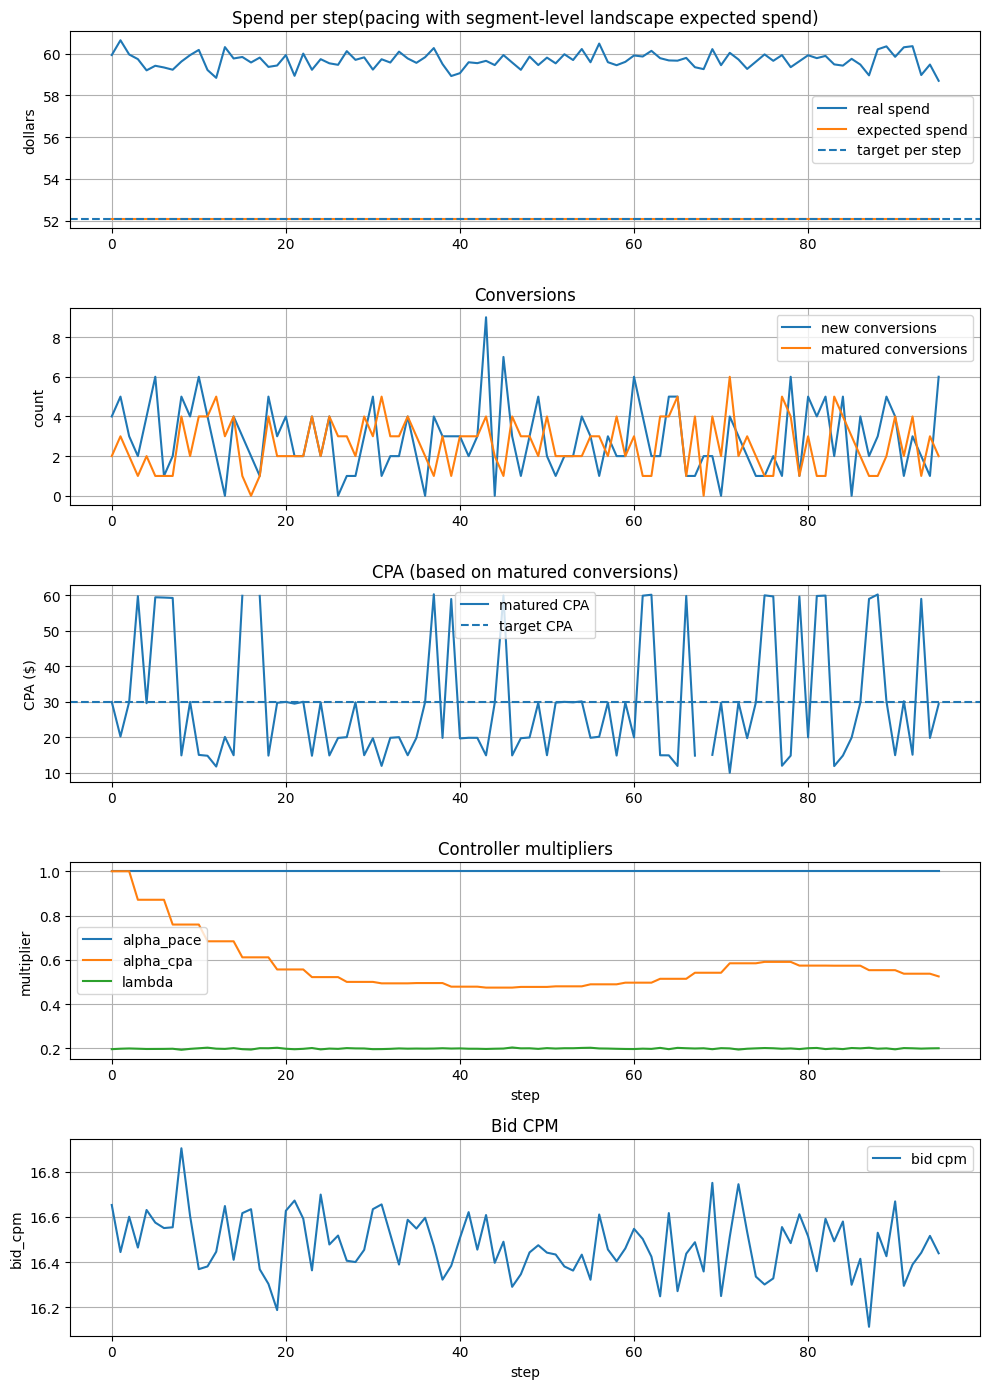

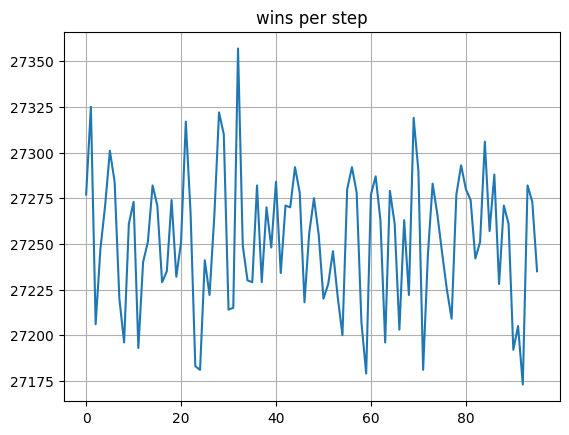

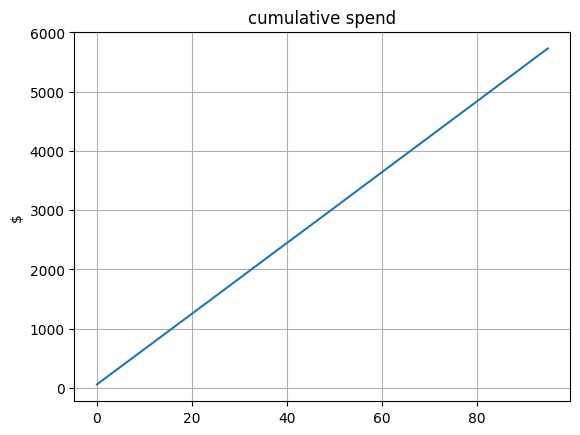

In [233]:
import numpy as np
import matplotlib.pyplot as plt

def plot_simulator_hist(hist, budget_total=None, target_cpa=None, pace_use_global_exp_s=False):

    T = len(hist["alpha_pace"])
    steps = np.arange(T)

    spend_real = np.array(hist["spend_real"])
    spend_exp  = np.array(hist["spend_exp"]) if not pace_use_global_exp_s else np.array(hist["spend_global_exp"])
    bid_cpm    = np.array(hist["bid_cpm"])
    conv_new   = np.array(hist["convs_new"])
    conv_mat   = np.array(hist["convs_matured"])
    cpa_mat    = np.array(hist["cpa_matured"])
    wins       = np.array(hist["wins"])

    alpha_pace = np.array(hist["alpha_pace"])
    alpha_cpa  = np.array(hist["alpha_cpa"])
    lam        = np.array(hist["lambda"])

    fig, axs = plt.subplots(5, 1, figsize=(10, 14))

    # -----------------------------
    # Spend per step
    # -----------------------------
    axs[0].plot(steps, spend_real, label="real spend")
    axs[0].plot(steps, spend_exp, label="expected spend")

    if budget_total is not None:
        target_step = budget_total / T
        axs[0].axhline(target_step, linestyle="--", label="target per step")

    axs[0].set_title("Spend per step(pacing with segment-level landscape expected spend)")
    axs[0].set_ylabel("dollars")
    axs[0].legend()
    axs[0].grid(True)


    # -----------------------------
    # Conversions
    # -----------------------------
    axs[1].plot(steps, conv_new, label="new conversions")
    axs[1].plot(steps, conv_mat, label="matured conversions")

    axs[1].set_title("Conversions")
    axs[1].set_ylabel("count")
    axs[1].legend()
    axs[1].grid(True)

    # -----------------------------
    # CPA
    # -----------------------------
    axs[2].plot(steps, cpa_mat, label="matured CPA")

    if target_cpa is not None:
        axs[2].axhline(target_cpa, linestyle="--", label="target CPA")

    axs[2].set_title("CPA (based on matured conversions)")
    axs[2].set_ylabel("CPA ($)")
    axs[2].legend()
    axs[2].grid(True)

    # -----------------------------
    # Multipliers
    # -----------------------------
    axs[3].plot(steps, alpha_pace, label="alpha_pace")
    axs[3].plot(steps, alpha_cpa, label="alpha_cpa")
    axs[3].plot(steps, lam, label="lambda")

    axs[3].set_title("Controller multipliers")
    axs[3].set_ylabel("multiplier")
    axs[3].set_xlabel("step")
    axs[3].legend()
    axs[3].grid(True)

    # -----------------------------
    # Bid CPMs
    # -----------------------------
    # print(bid_cpm)
    axs[4].plot(steps, bid_cpm, label="bid cpm")
    axs[4].set_title("Bid CPM")
    axs[4].set_ylabel("bid_cpm")
    axs[4].set_xlabel("step")
    axs[4].legend()
    axs[4].grid(True)

    plt.tight_layout()
    plt.show()

plot_simulator_hist(
    hist,
    budget_total=5000,
    target_cpa=30,
    pace_use_global_exp_s=False
)

# Win rate
plt.figure()
plt.plot(hist["wins"])
plt.title("wins per step")
plt.grid(True)

# Cumulative spend
cum_spend = np.cumsum(hist["spend_real"])

plt.figure()
plt.plot(cum_spend)
plt.title("cumulative spend")
plt.ylabel("$")
plt.grid(True)

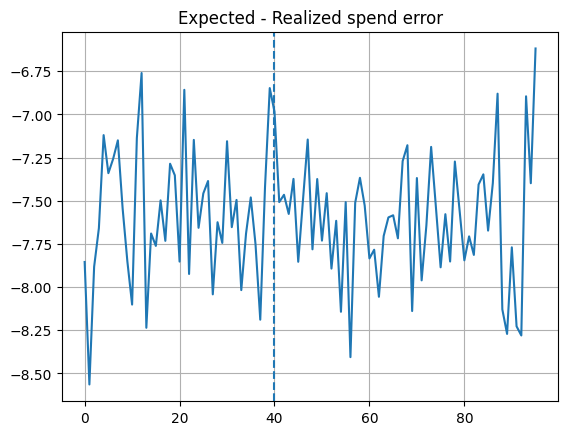

In [198]:
    # -----------------------------
    # Expected - Realized spend error per step
    # -----------------------------
    err = np.array(hist["spend_exp"]) - np.array(hist["spend_real"])
    plt.figure()
    plt.plot(err)
    plt.axvline(40, ls="--")
    plt.title("Expected - Realized spend error")
    plt.grid(True)
    plt.show()

In [199]:
import numpy as np
import matplotlib.pyplot as plt

def spend_response_curve(
    seg_id,
    market_price_cpm,
    pconv_hat,
    alpha_grid,
    target_cpa,
    base_mult=1.0,
):

    spends = []
    win_rates = []

    base_bid = 1000 * pconv_hat * target_cpa

    for alpha in alpha_grid:

        bid = base_mult * alpha * base_bid

        win = bid >= market_price_cpm

        spend = np.sum(market_price_cpm * win) / 1000.0
        win_rate = win.mean()

        spends.append(spend)
        win_rates.append(win_rate)

    return np.array(spends), np.array(win_rates)

# Plot spend response curve

In [200]:
alpha_grid = np.geomspace(0.05, 5.0, 40)

spend_curve, win_curve = spend_response_curve(
    seg_id=seg_id,
    market_price_cpm=sim["market_price_cpm"],
    pconv_hat=p_hat,
    alpha_grid=alpha_grid,
    target_cpa=50
)

In [201]:
alpha_grid = np.geomspace(0.05, 5.0, 40)

spend_curve, win_curve = spend_response_curve(
    seg_id=seg_id,
    market_price_cpm=sim["market_price_cpm"],
    pconv_hat=p_hat,
    alpha_grid=alpha_grid,
    target_cpa=50
)

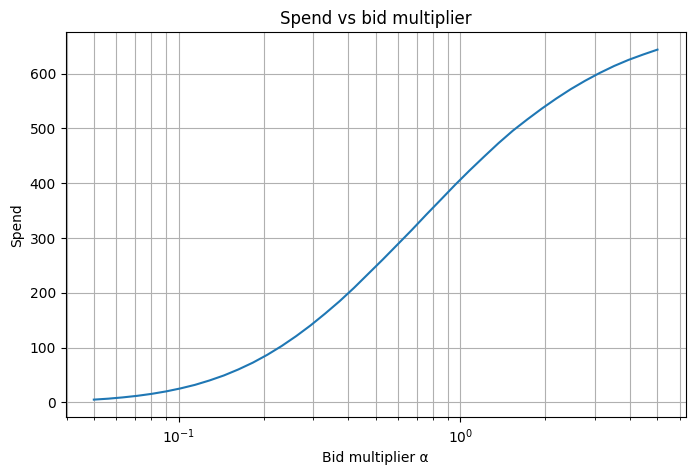

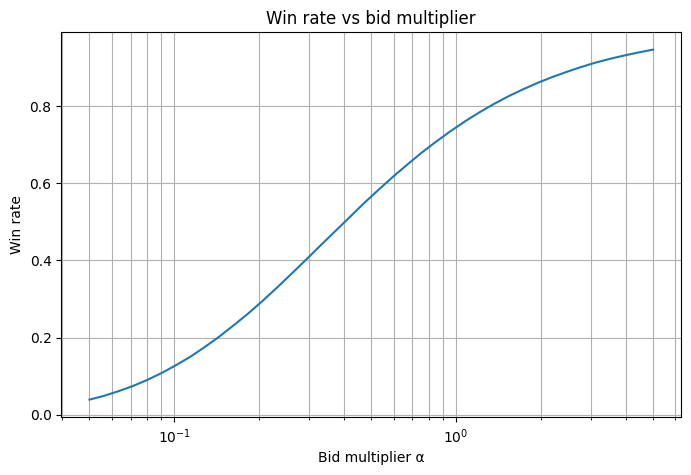

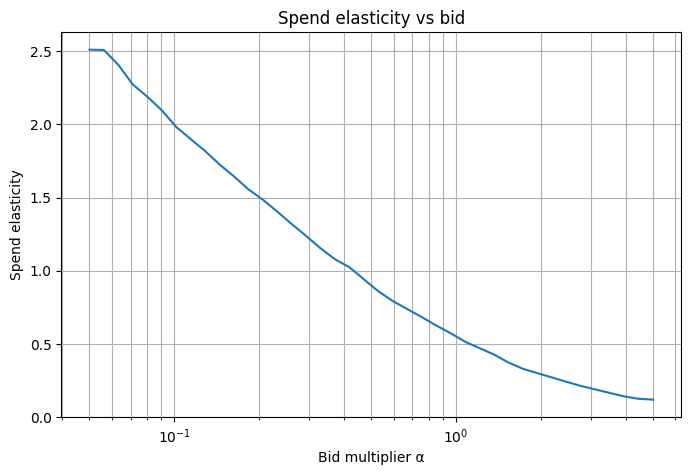

In [202]:
plt.figure(figsize=(8,5))

plt.semilogx(alpha_grid, spend_curve)

plt.xlabel("Bid multiplier α")
plt.ylabel("Spend")
plt.title("Spend vs bid multiplier")

plt.grid(True, which="both")
plt.show()

plt.figure(figsize=(8,5))

plt.semilogx(alpha_grid, win_curve)

plt.xlabel("Bid multiplier α")
plt.ylabel("Win rate")
plt.title("Win rate vs bid multiplier")

plt.grid(True, which="both")
plt.show()

elasticity = np.gradient(np.log(spend_curve), np.log(alpha_grid))

plt.figure(figsize=(8,5))
plt.semilogx(alpha_grid, elasticity)

plt.xlabel("Bid multiplier α")
plt.ylabel("Spend elasticity")
plt.title("Spend elasticity vs bid")

plt.grid(True, which="both")
plt.show()